In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import scipy.cluster.hierarchy as sch
from scipy.cluster.hierarchy import dendrogram, linkage 
from sklearn.metrics import silhouette_score


### قراءة البيانات

In [32]:
data=pd.read_excel('startup-expansion.xlsx')
data

,Store ID,City,State,Sales Region,New Expansion,Marketing Spend,Revenue
0,1,Peoria,Arizona,Region 2,Old,2601,48610
1,2,Midland,Texas,Region 2,Old,2727,45689
2,3,Spokane,Washington,Region 2,Old,2768,49554
3,4,Denton,Texas,Region 2,Old,2759,38284
4,5,Overland Park,Kansas,Region 2,Old,2869,59887
...,...,...,...,...,...,...,...
145,146,Paterson,New Jersey,Region 1,New,2251,34603
146,147,Brownsville,Texas,Region 2,New,3675,63148
147,148,Rockford,Illinois,Region 1,New,2648,43377
148,149,College Station,Texas,Region 2,New,2994,22457


### لمعرفة هل يوجد فيم فارغة

In [33]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Store ID         150 non-null    int64 
 1   City             150 non-null    object
 2   State            150 non-null    object
 3   Sales Region     150 non-null    object
 4   New Expansion    150 non-null    object
 5   Marketing Spend  150 non-null    int64 
 6   Revenue          150 non-null    int64 
dtypes: int64(3), object(4)
memory usage: 8.3+ KB


In [34]:
data.isnull().sum()


Store ID           0
City               0
State              0
Sales Region       0
New Expansion      0
Marketing Spend    0
Revenue            0
dtype: int64

### لمعرفة هل يوجد قيم شاذة

In [35]:
data.describe().round(2)

,Store ID,Marketing Spend,Revenue
count,150.00,150.00,150.00
mean,75.50,2893.15,39301.43
std,43.45,367.86,15465.75
min,1.00,1811.00,15562.00
25%,38.25,2662.25,21113.50
50%,75.50,2898.00,42993.00
75%,112.75,3111.50,51145.50
max,150.00,3984.00,68828.00


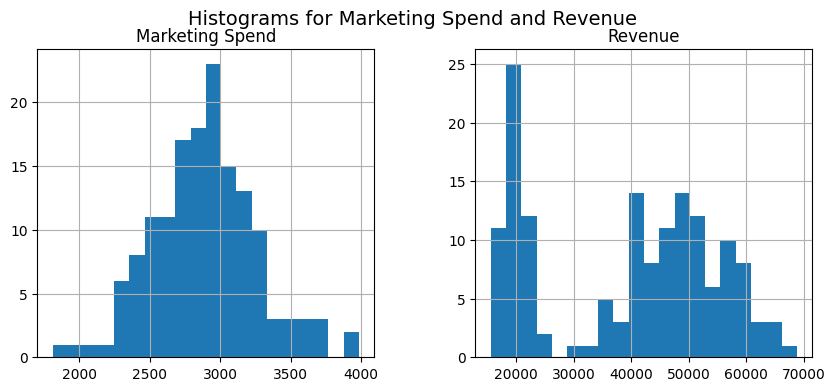

In [36]:
# اختيار الأعمدة المطلوبة فقط
cols_to_plot = ["Marketing Spend", "Revenue"]

# رسم الهستوجرام
data[cols_to_plot].hist(figsize=(10,4), bins=20)
plt.suptitle("Histograms for Marketing Spend and Revenue", fontsize=14)
plt.show()


### اكتشاف القيم الشاذة عن طريق الربيعيات

In [ ]:

def detect_outliers_all(df, columns):
    all_outliers = pd.DataFrame()  # لإنشاء DataFrame فارغ لتجميع النتائج
    
    for column in columns:
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)].copy()
        outliers["Outlier_Column"] = column  # إضافة عمود يوضح في أي عمود تم اكتشاف الشذوذ
        
        all_outliers = pd.concat([all_outliers, outliers])
    
    return all_outliers

# استخدام الدالة على Marketing Spend و Revenue
outliers_df = detect_outliers_all(data, ["Marketing Spend", "Revenue"])

print("جميع القيم الشاذة:")
print(outliers_df)


جميع القيم الشاذة:
     Store ID       City       State Sales Region New Expansion  \
62         63   Richmond  California     Region 2           Old   
86         87   Amarillo       Texas     Region 2           Old   
135       136  San Mateo  California     Region 2           Old   

     Marketing Spend  Revenue   Outlier_Column  
62              3924    19448  Marketing Spend  
86              3984    56089  Marketing Spend  
135             1811    19426  Marketing Spend  


In [38]:
'''
# تطبيق اللوغاريتم على العمودين
data["Marketing Spend_log"] = np.log1p(data["Marketing Spend"])  # log(1+x) لتجنب log(0)
data["Revenue_log"] = np.log1p(data["Revenue"])  # log(1+x) لتجنب log(0)'''


'\n# تطبيق اللوغاريتم على العمودين\ndata["Marketing Spend_log"] = np.log1p(data["Marketing Spend"])  # log(1+x) لتجنب log(0)\ndata["Revenue_log"] = np.log1p(data["Revenue"])  # log(1+x) لتجنب log(0)'

### قص القيم

In [39]:
# قص القيم الشاذة عند حدود IQR
for col in ["Marketing Spend"]:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    
    data[col] = data[col].clip(lower, upper)


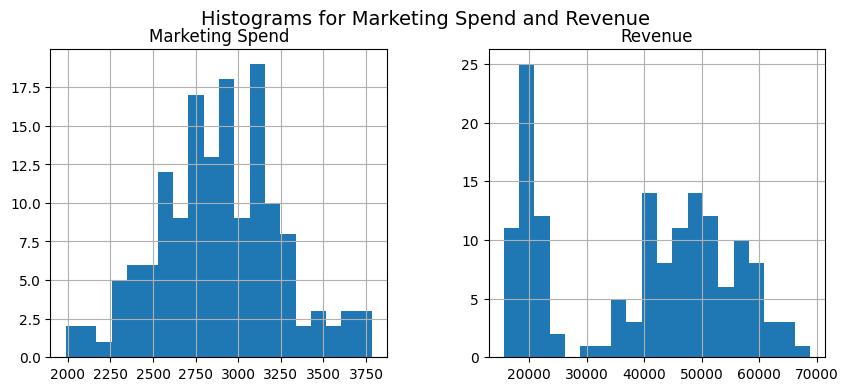

In [40]:

# اختيار الأعمدة المطلوبة فقط
cols_to_plot = ["Marketing Spend", "Revenue"]

# رسم الهستوجرام
data[cols_to_plot].hist(figsize=(10,4), bins=20)
plt.suptitle("Histograms for Marketing Spend and Revenue", fontsize=14)
plt.show()


### اضافة عمود للايرادات بعد خصم الانفاق

In [41]:
data["ROI"] = (data["Revenue"] - data["Marketing Spend"]) / data["Marketing Spend"]

In [42]:
data

,Store ID,City,State,Sales Region,New Expansion,Marketing Spend,Revenue,ROI
0,1,Peoria,Arizona,Region 2,Old,2601.0,48610,17.688966
1,2,Midland,Texas,Region 2,Old,2727.0,45689,15.754309
2,3,Spokane,Washington,Region 2,Old,2768.0,49554,16.902457
3,4,Denton,Texas,Region 2,Old,2759.0,38284,12.876042
4,5,Overland Park,Kansas,Region 2,Old,2869.0,59887,19.873824
...,...,...,...,...,...,...,...,...
145,146,Paterson,New Jersey,Region 1,New,2251.0,34603,14.372279
146,147,Brownsville,Texas,Region 2,New,3675.0,63148,16.183129
147,148,Rockford,Illinois,Region 1,New,2648.0,43377,15.381042
148,149,College Station,Texas,Region 2,New,2994.0,22457,6.500668


### هل الفروع الجديدة تحقق إيرادات أعلى من القديمة أم لا؟
### متوسط الإيرادات حسب التوسّع

<Axes: xlabel='New Expansion'>

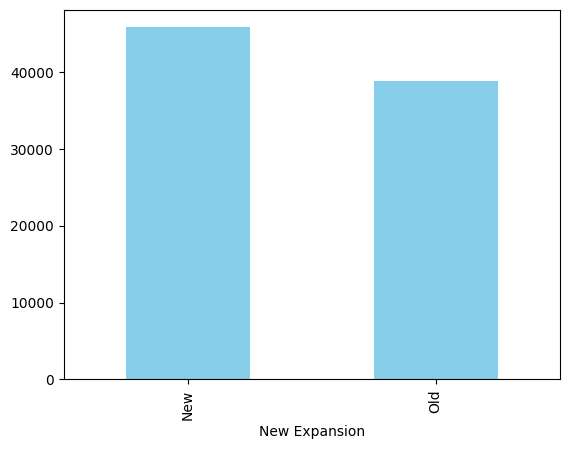

In [43]:
data.groupby("New Expansion")["Revenue"].mean().plot(kind="bar", color="skyblue")

### متوسط الإيرادات حسب Sales Region

<Axes: xlabel='Sales Region'>

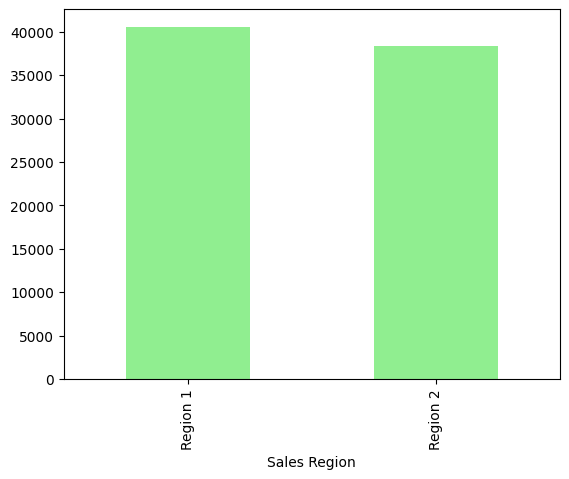

In [44]:
data.groupby("Sales Region")["Revenue"].mean().plot(kind="bar", color="lightgreen")

### أعلى المدن من حيث الإيرادات

<Axes: xlabel='City'>

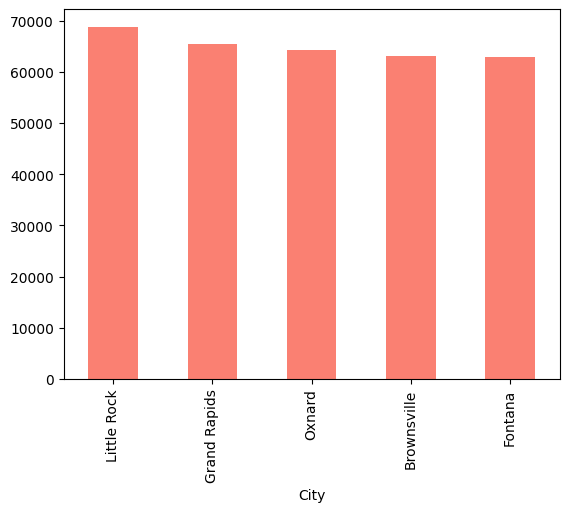

In [45]:
data.groupby("City")["Revenue"].mean().sort_values(ascending=False).head(5).plot(kind="bar", color="salmon")


### العلاقة بين الإنفاق والإيرادات


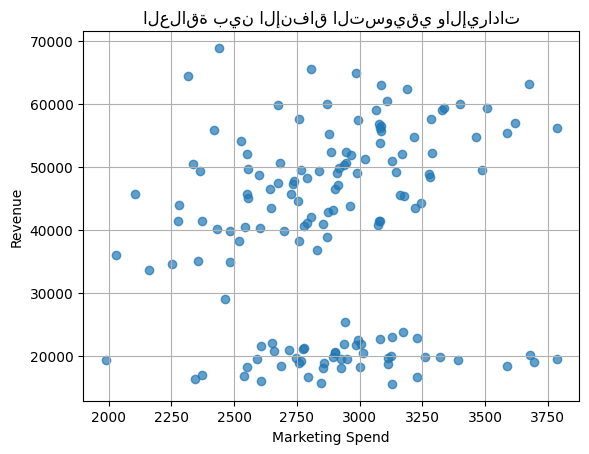

In [46]:

plt.scatter(data["Marketing Spend"], data["Revenue"], alpha=0.7)
plt.xlabel("Marketing Spend")
plt.ylabel("Revenue")
plt.title("العلاقة بين الإنفاق التسويقي والإيرادات")
plt.grid(True)
plt.show()

## تدريب مودل

### تحضير البيانات

In [47]:
features = data[["Marketing Spend", "Revenue", "ROI"]]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

### تحديد عدد التجمعات المثالي 

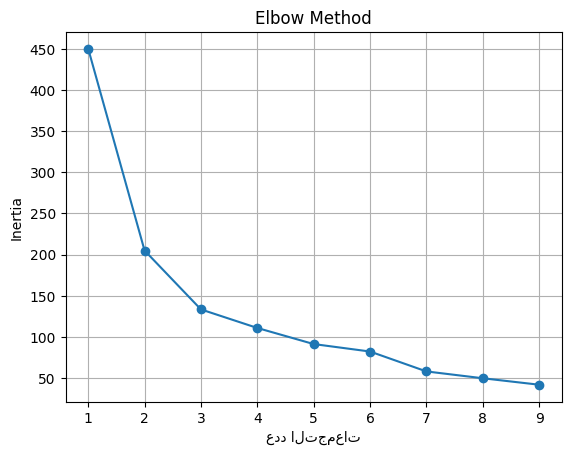

In [48]:
inertia = []
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 10), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("عدد التجمعات")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

### تجربة KMeans

In [49]:
kmeans = KMeans(n_clusters=3, random_state=42)
data["KMeans_Cluster"] = kmeans.fit_predict(X_scaled)

data.groupby("KMeans_Cluster")[["Marketing Spend", "Revenue", "ROI"]].mean()

,Marketing Spend,Revenue,ROI
KMeans_Cluster,,,
0,3135.543981,52676.203704,15.850062
1,2957.987245,19722.755102,5.724757
2,2543.646277,44346.489362,16.491796


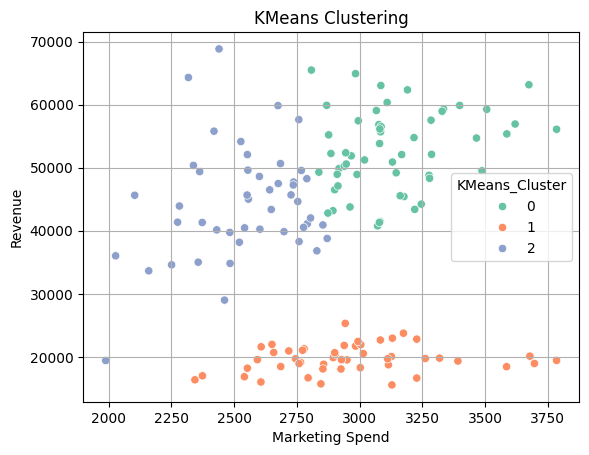

In [50]:

sns.scatterplot(
    data=data,
    x="Marketing Spend",
    y="Revenue",
    hue="KMeans_Cluster",
    palette="Set2"
)
plt.title("KMeans Clustering")
plt.grid(True)
plt.show()


### تجربة Agglomerative Clustering

In [51]:
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=3)
data["Agg_Cluster"] = agg.fit_predict(X_scaled)

# تحليل التجمعات
data.groupby("Agg_Cluster")[["Marketing Spend", "Revenue", "ROI"]].mean()

,Marketing Spend,Revenue,ROI
Agg_Cluster,,,
0,2938.59500,19716.820000,5.785658
1,2604.12963,45608.907407,16.605419
2,3179.55163,53184.630435,15.772942


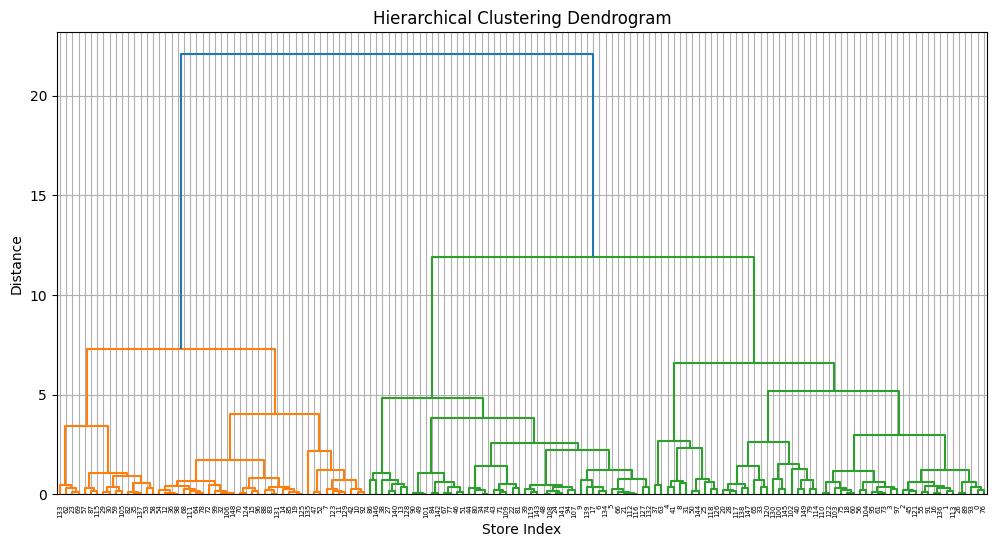

In [52]:


plt.figure(figsize=(12, 6))
dendrogram(sch.linkage(X_scaled, method='ward'))
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Store Index")
plt.ylabel("Distance")
plt.grid(True)
plt.show()

### تقييم جودة النماذج


In [53]:

print("🔹 KMeans Score:", silhouette_score(X_scaled, data["KMeans_Cluster"]))
print("🔹 Agglomerative Score:", silhouette_score(X_scaled, data["Agg_Cluster"]))


🔹 KMeans Score: 0.46152260374747056
🔹 Agglomerative Score: 0.4495902267874767


## نعتمد القيمة الاعلى للتقييم وهو K-Means

# أهداف المشروع:
### فهم تأثير التسويق والتوسّع على الإيرادات
### تحليل الأداء عبر المناطق
### تصنيف المتاجر إلى مجموعات متشابهة

# النتيجة
## تم تصنيف المتاجر إلى مجموعات ذات أنماط أداء مختلفة


In [54]:
# 1. حساب متوسط ROI لكل Cluster وترتيبهم
roi_means = data.groupby("KMeans_Cluster")["ROI"].mean().sort_values(ascending=False)
sorted_clusters = roi_means.index.tolist()

# 2. إعداد التسميات حسب الترتيب
performance_labels = {
    0: "🟢 أداء ممتاز",
    1: "🔵 أداء جيد",
    2: "🟠 أداء ضعيف"
}

# 3. ربط كل Cluster بالتسمية الصحيحة
cluster_to_label = {cluster_id: performance_labels[i] for i, cluster_id in enumerate(sorted_clusters)}

# 4. تطبيق التسميات
data["Cluster Label"] = data["KMeans_Cluster"].map(cluster_to_label)
print(data[["City","Marketing Spend" ,"Revenue", "ROI", "KMeans_Cluster", "Cluster Label"]].sample(10))

                 City  Marketing Spend  Revenue        ROI  KMeans_Cluster  \
13            Jackson         3466.000    54701  14.782170               0   
59          Davenport         3175.000    23764   6.484724               1   
86           Amarillo         3785.375    56089  13.817290               0   
54        West Covina         2939.000    21824   6.425655               1   
50              Akron         2338.000    50364  20.541488               2   
87         High Point         3262.000    19752   5.055181               1   
49             Olathe         3082.000    41460  12.452304               0   
11        Santa Maria         2651.000    21988   7.294229               1   
23            Burbank         3679.000    20123   4.469693               1   
118  Huntington Beach         2527.000    54145  20.426593               2   

    Cluster Label  
13     🔵 أداء جيد  
59    🟠 أداء ضعيف  
86     🔵 أداء جيد  
54    🟠 أداء ضعيف  
50   🟢 أداء ممتاز  
87    🟠 أداء ضعيف  
4